In [1]:
from itertools import combinations
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / "counts.zarr")
repack_store(
    f"{dataset}/data.zarr",
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / "dimensionality_analysis.zarr"),
    default_assay="RNA",
    nthreads=4,
    min_features_per_cell=10,
)
cell_selection = ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
)
hvg_ref = ds.select_hvgs(
    cell_selection,
    min_cells=20,
    top_n=500,
    show_plot=False,
)
normalized = ds.run_normalization(cell_selection, hvg_ref)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

...

Repacking RNA/artifacts/cluster_hierarchy//children: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

  RNA/counts: shape=(5025, 33538), dtype=uint32, chunks=(5025, 4791), shards=(5025, 38328)


Calculating feature statistics: 30 / 30 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

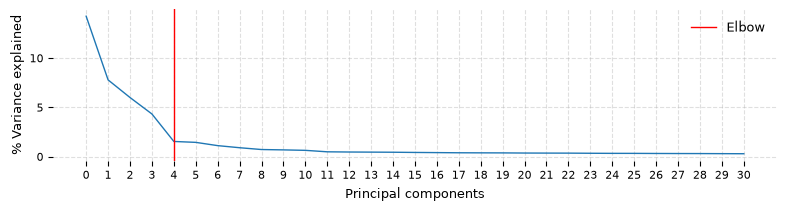

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

In [2]:
cluster_refs = {}
pca_refs = {}
graph_refs = {}
for dimensions in (10, 30, 15):
    pca = ds.run_pca(
        normalized,
        dims=dimensions,
        show_elbow_plot=dimensions == 30,
    )
    pca_refs[dimensions] = pca
    ann = ds.build_ann_index(pca)
    neighbors = ds.query_neighbors(ann, k=11)
    graph = ds.build_connectivity_map(neighbors)
    graph_refs[dimensions] = graph

    cluster_refs[dimensions] = ds.run_leiden_clustering(
        graph,
        resolution=0.5,
    )

initialization_15 = ds.build_embedding_initialization(pca_refs[15])

In [3]:
scores_30 = np.asarray(ds.load_artifact(pca_refs[30])["data"])
retained_share = scores_30.var(axis=0, ddof=1)
retained_share = 100.0 * retained_share / retained_share.sum()
cumulative_share = np.cumsum(retained_share)
pd.Series(
    {
        dimensions: float(cumulative_share[dimensions - 1])
        for dimensions in (10, 15, 30)
    },
    name="cumulative_share_of_30pc_fit",
).rename_axis("pca_dimensions")

pca_dimensions
10    83.311363
15    88.653770
30    99.999992
Name: cumulative_share_of_30pc_fit, dtype: float64

In [4]:
cluster_counts = pd.Series(
    {
        dimensions: pd.Series(
            np.asarray(ds.load_artifact(cluster_ref)["values"][:])
        ).nunique()
        for dimensions, cluster_ref in cluster_refs.items()
    },
    name="n_clusters",
).rename_axis("pca_dimensions")
cluster_counts

pca_dimensions
10    10
30    11
15    12
Name: n_clusters, dtype: int64

In [5]:
cluster_sizes = pd.DataFrame(
    {
        dimensions: pd.Series(
            np.asarray(ds.load_artifact(cluster_ref)["values"][:])
        ).value_counts()
        for dimensions, cluster_ref in cluster_refs.items()
    }
).fillna(0).astype(int)
cluster_sizes

,10,30,15
1,724,698,694
2,233,233,28
3,1286,12,237
4,466,1255,1004
5,286,316,317
6,514,337,539
7,139,140,142
8,265,264,263
9,15,645,378
10,12,25,311


In [6]:
agreement_rows = []
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

cluster_values = {
    dimensions: np.asarray(ds.load_artifact(ref)["values"][:])
    for dimensions, ref in cluster_refs.items()
}
for first, second in combinations(cluster_refs, 2):
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second} dimensions",
            "ARI": adjusted_rand_score(cluster_values[first], cluster_values[second]),
            "NMI": normalized_mutual_info_score(
                cluster_values[first],
                cluster_values[second],
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,10 vs 30 dimensions,0.866250,0.870367
1,10 vs 15 dimensions,0.790504,0.864232
2,30 vs 15 dimensions,0.756990,0.846109


In [7]:
umap = ds.run_umap(
    graph_refs[15],
    initialization_15,
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
)

Training UMAP: 150 / 150 complete

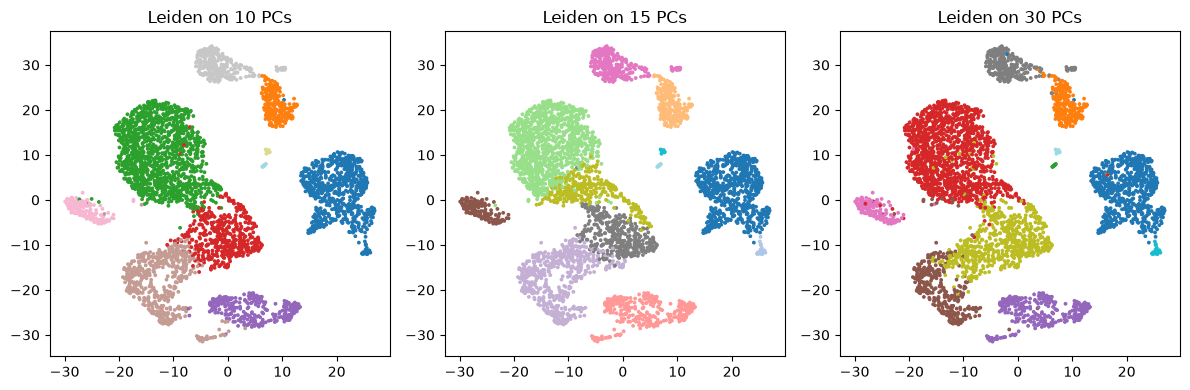

In [8]:
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, dimensions in zip(
    axes,
    (10, 15, 30),
    strict=True,
):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=cluster_values[dimensions],
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"Leiden on {dimensions} PCs")
figure.tight_layout()
figure

In [9]:
umap_tight = ds.run_umap(
    graph_refs[15],
    initialization_15,
    n_epochs=150,
    spread=5,
    min_dist=0.1,
    parallel=True,
)

Training UMAP: 150 / 150 complete

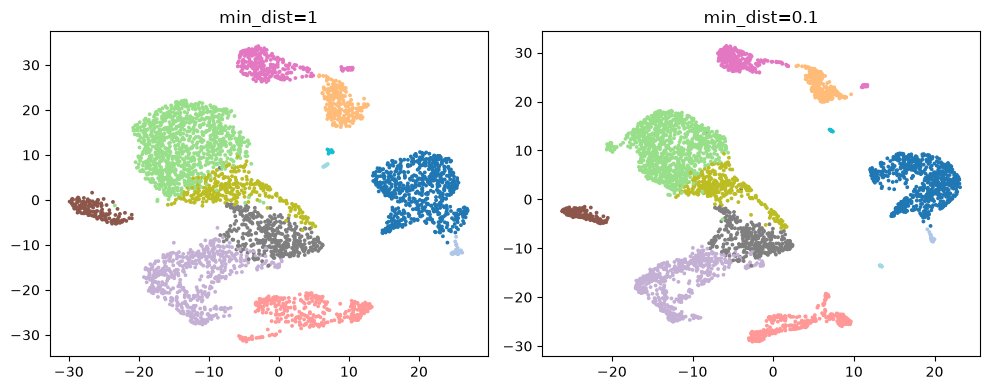

In [10]:
umap_tight_values = np.asarray(ds.load_artifact(umap_tight)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, coordinates, title in zip(
    axes,
    (umap_values, umap_tight_values),
    ("min_dist=1", "min_dist=0.1"),
    strict=True,
):
    axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=cluster_values[15],
        s=3,
        cmap="tab20",
    )
    axis.set_title(title)
figure.tight_layout()
figure

In [11]:
densmap = ds.run_umap(
    graph_refs[15],
    initialization_15,
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
)

Training UMAP: 150 / 150 complete

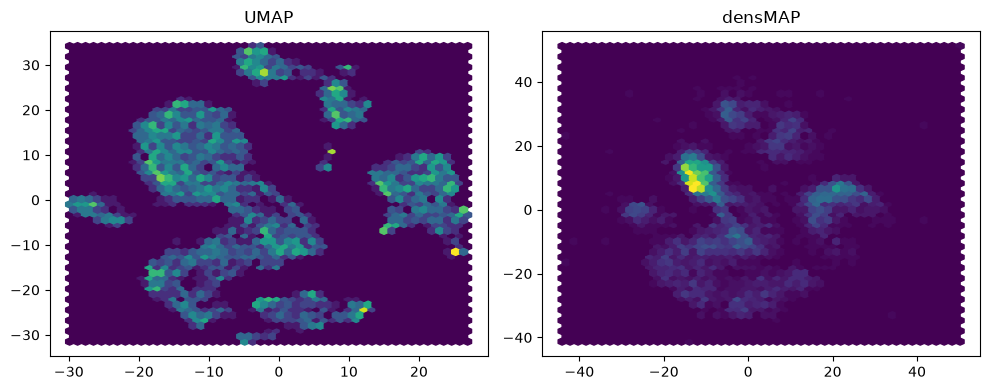

In [12]:
dense_values = np.asarray(ds.load_artifact(densmap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, coordinates, title in zip(
    axes,
    (umap_values, dense_values),
    ("UMAP", "densMAP"),
    strict=True,
):
    axis.hexbin(coordinates[:, 0], coordinates[:, 1], gridsize=50)
    axis.set_title(title)
figure.tight_layout()
figure

In [13]:
tsne = ds.run_tsne(
    graph_refs[15],
    initialization_15,
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    verbose=False,
)

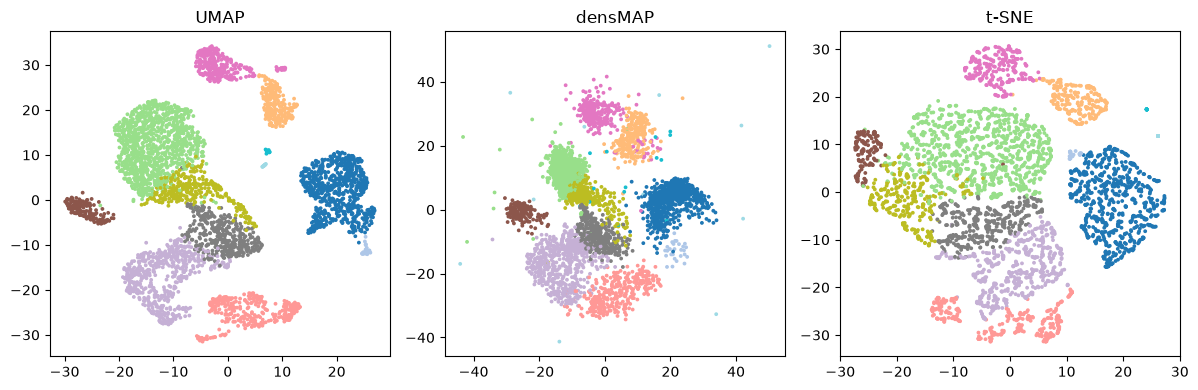

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
tsne_values = np.asarray(ds.load_artifact(tsne)["values"][:])
layout_comparisons = (
    ("UMAP", umap_values),
    ("densMAP", dense_values),
    ("t-SNE", tsne_values),
)
for axis, (title, coordinates) in zip(
    axes,
    layout_comparisons,
    strict=True,
):
    axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=cluster_values[15],
        s=3,
        cmap="tab20",
    )
    axis.set_title(title)
figure.tight_layout()
figure